# MySQL mock exam exercises

## Setup

In [1]:
import matplotlib.pyplot as plt
from IPython.display import Image

In [2]:
%reload_ext sql
%env DATABASE_URL=mysql+mysqlconnector://root:root_pwd@db
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

env: DATABASE_URL=mysql+mysqlconnector://root:root_pwd@db


## `world` database

In [3]:
%%sql
CREATE DATABASE IF NOT EXISTS world;

1 rows affected.


[]

```bash
$ mysql -u root -p world < /mapd-workspace/dbs/world.sql
```

In [4]:
%%sql
USE world;

 * mysql+mysqlconnector://root:***@db
0 rows affected.


[]

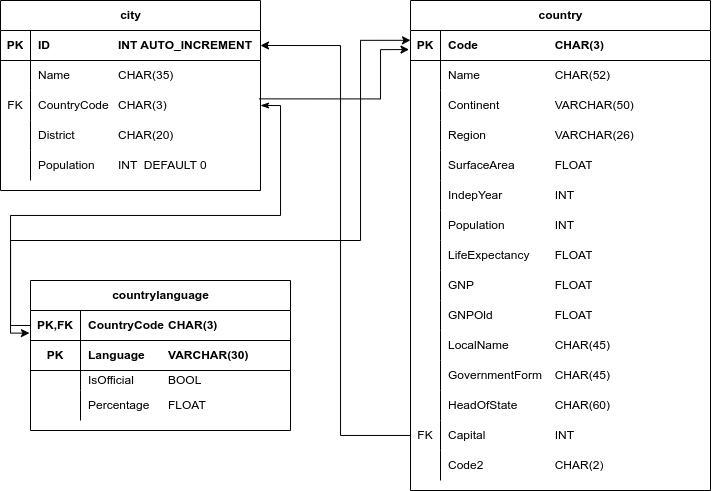

In [5]:
Image("/mapd-workspace/dbs/world_complete_schema.png")
#---> NB this path bc from inside container

### 22
Using the `world` database, write a single SQL query to retrieve the average population of cities in each country that has a population greater than 10 million, grouped by continent.

In [17]:
%%sql
SELECT country.continent, ROUND(AVG(city.Population),0) AS "Average city population \n for highly populated countries"
FROM city
JOIN country on country.Code=city.CountryCode
WHERE country.Population > 10e6
GROUP BY country.Continent
ORDER BY AVG(city.Population) DESC
LIMIT 5;

 * mysql+mysqlconnector://root:***@db
5 rows affected.


continent,Average city population for highly populated countries
Oceania,808119
Asia,395951
Africa,384686
South America,367223
North America,305267


In [ ]:
#---> unclear task. If they meant keeping continents separate:

In [26]:
%%sql
SELECT country.continent, country.Name, ROUND(AVG(city.Population),0) AS avg_city_pop
FROM city
JOIN country on country.Code=city.CountryCode
WHERE country.Population > 10e6
GROUP BY country.Code
ORDER BY country.Continent, avg_city_pop DESC
LIMIT 5;

 * mysql+mysqlconnector://root:***@db
5 rows affected.


continent,Name,avg_city_pop
Asia,Thailand,662763
Asia,Iraq,595069
Asia,Afghanistan,583025
Asia,South Korea,557141
Asia,Pakistan,534691


In [ ]:
#---> NB the double ORDER BY in this order

### 23
Using the `world` database, write a single SQL query to retrieve the total number of languages spoken in countries that are located in Asia and have a population greater than 50 million, grouped by region.

In [32]:
%%sql
SELECT C.region, SUM(1) AS tot_languages
FROM countrylanguage AS CL
JOIN country AS C ON CL.CountryCode=C.Code
WHERE C.continent="Asia" 
 AND C.Population > 50e6
GROUP BY C.region
ORDER BY tot_languages DESC
LIMIT 5;

 * mysql+mysqlconnector://root:***@db
4 rows affected.


region,tot_languages
Southern and Central Asia,37
Southeast Asia,34
Eastern Asia,18
Middle East,3


## `IMDb` database

In [34]:
%%sql
CREATE DATABASE IF NOT EXISTS IMDb;

 * mysql+mysqlconnector://root:***@db
1 rows affected.


[]

In [47]:
%%sql
USE IMDb;

 * mysql+mysqlconnector://root:***@db
0 rows affected.


[]

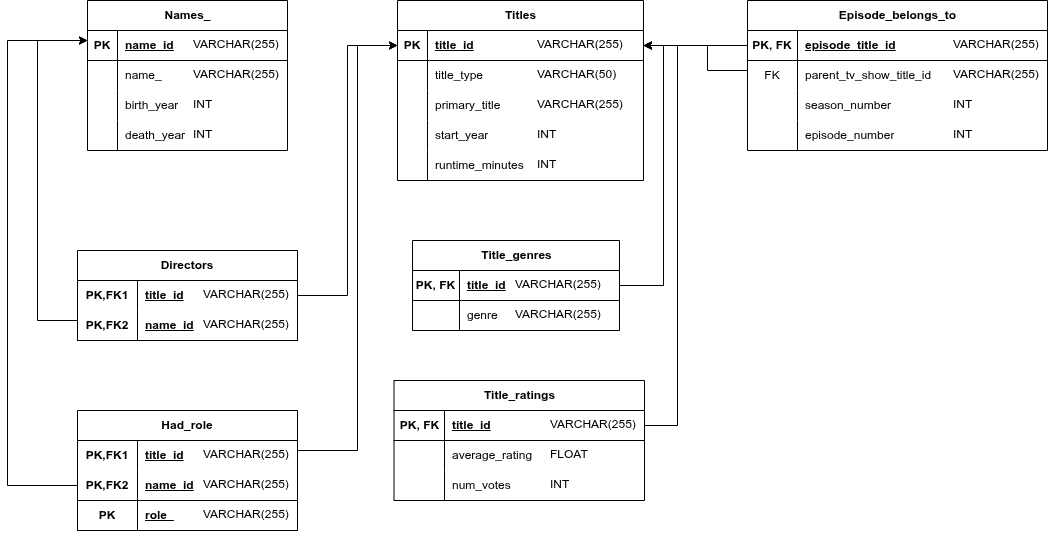

In [44]:
Image("/mapd-workspace/dbs/IMDb_schema.png")

### 24

Using the `IMDb` database, write a single SQL query to retrieve the average movie rating of movies in the "Action" genre that have a runtime of more than 90 minutes, grouped by year.

In [48]:
%%sql
SELECT T.start_year, ROUND(AVG(TR.average_rating),2) AS avg_rating
FROM Titles AS T
JOIN Title_genres AS TG ON TG.title_id=T.title_id 
JOIN Title_ratings AS TR ON TR.title_id=T.title_id
WHERE T.title_type="movie"
 AND TG.genre="Action"
 AND T.runtime_minutes > 90
GROUP BY T.start_year
ORDER BY avg_rating DESC
LIMIT 5;

 * mysql+mysqlconnector://root:***@db
5 rows affected.


start_year,avg_rating
2022,6.8
2021,6.12
2014,5.88
2017,5.88
2018,5.82


### 25
Using the IMDb database, write a single SQL query to retrieve the top 5 persons who have worked in the most movies, ordered by the number of movies in which they have worked.

In [ ]:
#---> slighlty unclear; if only actors:

In [ ]:
%%sql
SELECT N.name_, N.birth_year, N.death_year, COUNT(DISTINCT(HR.title_id)) AS tot_movies
FROM Had_role AS HR
JOIN Titles AS T ON HR.title_id=T.title_id
#JOIN Directors AS D ON D.title_id=T.title_id
JOIN Names_ AS N ON HR.name_id=N.name_id# OR D.name_id=N.name_id)
GROUP BY N.name_id
ORDER BY tot_movies DESC
LIMIT 5;

 * mysql+mysqlconnector://root:***@db


In [ ]:
#---> slow bc no indexes again -> TODO ADD THEM??
#    NB the DISTINCT in case multiple roles in same movie 

#---> if instead also directors:

In [ ]:
%%sql 
SELECT N.name_, COUNT(*) AS tot_movies
FROM (
    SELECT name_id, title_id FROM Had_role
    UNION
    SELECT name_id, title_id FROM Directors
) AS roles
JOIN Names_ N ON N.name_id = roles.name_id
GROUP BY N.name_id
ORDER BY tot_movies DESC
LIMIT 5;

In [ ]:
#---> NB UNION simply merges records, ie rows (must be compatible columns)
#---> TODO try to run it??

### 26
Using the IMDb database, retrieve the average rating of movies in the "Comedy" genre, which were released after 2000 and have more than 100,000 votes, grouped by director, but only for directors who have directed more than 5 movies.

### 27
Using the IMDb database, retrieve the total number of movies and the average runtime of movies in each genre, but only for genres with more than 10 movies released after 2010. Group the results by genre and filter out any genres where the average runtime is less than 90 minutes.